In [79]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import _canoeValues as cv
import math

def draw_mohrs_circles(fc, ft, sigma_comp, sigma_tens):
    """
    fc           = compressive strength (positive number, MPa)
    ft           = tensile strength (positive number, MPa)
    sigma_comp   = applied compressive stress (negative)
    sigma_tens   = applied tensile stress (positive)
    """

    # -----------------------------
    # Strength circles
    # -----------------------------
    Cc = -fc / 2
    Rc = fc / 2

    Ct = ft / 2
    Rt = ft / 2

    # -----------------------------
    # Applied stress circle
    # -----------------------------
    C_app = (sigma_tens + sigma_comp) / 2
    R_app = (sigma_tens - sigma_comp) / 2

    # -----------------------------
    # Tangent line
    # -----------------------------
    dC = Cc - Ct
    dR = Rc - Rt
    m = np.sign(dC) * dR / np.sqrt(dC**2 - dR**2)
    b = Rc * np.sqrt(1 + m**2) - m * Cc

    # -----------------------------
    # Plotting
    # -----------------------------
    theta = np.linspace(0, 2*np.pi, 400)

    BLUE   = "#2166AC"
    RED    = "#D6604D"
    GREEN  = "#4DAC26"
    ORANGE = "#F4A582"

    fig, ax = plt.subplots()


    # Strength circles
    ax.plot(Cc + Rc*np.cos(theta), Rc*np.sin(theta),
            color=BLUE, linewidth=2, label="Compressive Strength Circle")
    ax.plot(Ct + Rt*np.cos(theta), Rt*np.sin(theta),
            color=RED, linewidth=2, label="Tensile Strength Circle")

    # Applied stress circle
    ax.plot(C_app + R_app*np.cos(theta), R_app*np.sin(theta),
            color=GREEN, linewidth=2, linestyle='-', label="Applied Stress Circle")

    # Tangent / failure envelope
    x_vals = np.linspace(-fc*1.3, ft*1.3, 400)
    y_vals = m*x_vals + b
    # Clip to positive shear half for clarity
    mask = y_vals >= 0
    ax.plot(x_vals[mask], y_vals[mask],
            color="#555555", linewidth=1.5, linestyle='--', label="Failure Envelope")
    ax.plot(x_vals[mask], -y_vals[mask],
            color="#555555", linewidth=1.5, linestyle='--')

    # -----------------------------
    # Key points
    # -----------------------------
    key_points = {
        f"{-fc:.1f}": (-fc, 0),
        f"{ft:.1f}":  ( ft, 0),
        f"{sigma_comp:.1f}": (sigma_comp, 0),
        f"{sigma_tens:.1f}": (sigma_tens, 0),
    }

    point_colors = {
        f"{-fc:.1f}": BLUE,
        f"{ft:.1f}":  RED,
        f"{sigma_comp:.1f}": GREEN,
        f"{sigma_tens:.1f}": GREEN,
    }

    for label, (x, y) in key_points.items():
        color = point_colors[label]
        ax.plot(x, y, 'o', color=color, markersize=5, zorder=5)
        offset = (8, 3) if x >= 0 else (-12,3)
        ax.annotate(label, xy=(x, y), xytext=offset,
                    textcoords='offset points',
                    fontsize=8, color=color, fontweight='bold',
                    ha='center', va='bottom')

    # -----------------------------
    # Axes and grid
    # -----------------------------
    ax.axhline(0, color='black', linewidth=0.8, zorder=1)
    ax.axvline(0, color='black', linewidth=0.8, zorder=1)

    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlabel("Normal Stress  $\\sigma$ (MPa)", fontsize=11)
    ax.set_ylabel("Shear Stress  $\\tau$ (MPa)", fontsize=11)

    # # Ticks: place them at the key stress values
    # x_ticks = sorted(set([0, -fc, ft, sigma_comp, sigma_tens]))
    # ax.set_xticks(x_ticks)
    # ax.xaxis.set_tick_params(labelsize=8)
    # ax.yaxis.set_tick_params(labelsize=8)


    ax.grid(True, linestyle=':', linewidth=0.6, color='#CCCCCC')
    ax.spines[['top', 'right']].set_visible(False)

    #ax.legend(loc='upper right', fontsize=9, framealpha=0.7)

    ax.set_xlim(-fc * 1.1, ft * 1.1)
    ax.set_ylim(-(Rc * 1.2), Rc * 1.2)
    plt.tight_layout()
    plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


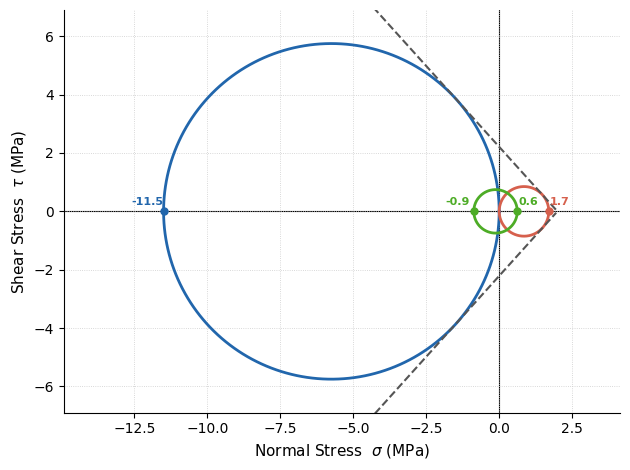

In [80]:
fc = cv.compressive_strength
ft = cv.tensile_strength
C_app = 0.87
T_app = 0.62
draw_mohrs_circles(fc,ft,-C_app,T_app)